# Central Moment

This section is a numerical introduction to the concept of central moment in the chromatographic context. Symbolic calculation will [later](characteristic_function) be introduced using [SymPy](https://www.sympy.org/en/index.html).

## Simple Numerical Examples

By "chromatographic context", the following points are suggested.

* We will consider the averaging of retention time (x axes in the following figures),
* weighted by concentration (y axes).

### Uniformly weighted Average

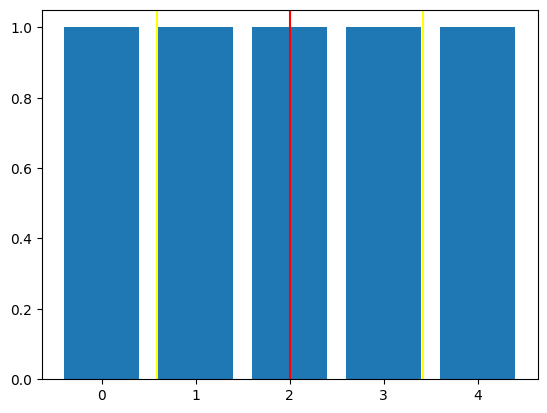

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 5
x = np.arange(N)
w = np.ones(N)     # uniform weights
plt.bar(x, w)
m = np.mean(x)
s = np.std(x)
plt.axvline(m, color='red')
for p in m-s, m+s:
    plt.axvline(p, color='yellow')

### Averaging with Guassian Weights

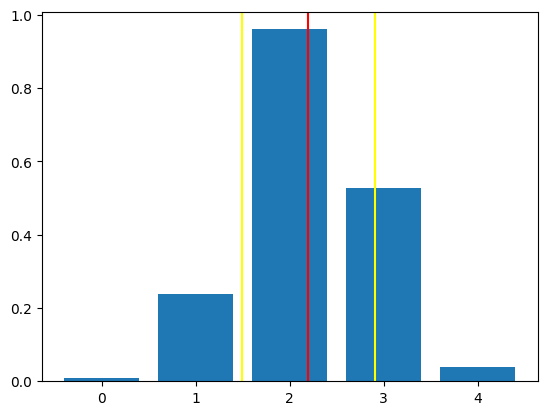

In [2]:
w = np.exp(-(x-2.2)**2)    # non-uniform (gaussian) weights

u = 0
v = 0
for i in range(N):
    u += w[i]*x[i]
    v += w[i]

m = u/v

z = 0
v = 0
for i in range(N):
    z += w[i]*(x[i] - m)**2
    v += w[i]
    
v, z, z/v, np.sqrt(z/v)

s = np.sqrt(z/v)
plt.bar(x, w)
plt.axvline(m, color='red')
for p in m-s, m+s:
    plt.axvline(p, color='yellow')

## Do it faster in NumPy
### 0th Raw Moment

In [3]:
M0 = np.sum(w)
M0

np.float64(1.772080571028074)

### 1st Raw Moment or Mean

In [4]:
M1 = np.sum(w*x)/M0
M1

np.float64(2.199132225263884)

### 2nd Central Moment and Standard Deviation

In [5]:
M2 = np.sum(w*(x - M1)**2)/M0
M2, np.sqrt(M2)

(np.float64(0.49785237938665794), np.float64(0.7055865498906976))